# ============================================================
# THESIS: Modeling and Forecasting Stock Prices in the
# NASDAQ-100 Index Using ARIMA and SARIMA
# Stock: AMAZON (AMZN)
# Author: William Sanjaya Kesuma
# ============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import requests
import warnings
warnings.filterwarnings('ignore')
 
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import pmdarima as pm

In [2]:
print("=" * 60)
print("STEP 1: LOADING DATA")
print("=" * 60)

url = "https://raw.githubusercontent.com/WilliamKesuma/Stock-Data-Analysis/refs/heads/main/AMZN%20-Price%20History_20260331_0845.csv"
response = requests.get(url)

# Find the row where actual daily data begins
lines = response.text.splitlines()
header_row = None
for i, line in enumerate(lines):
    if line.startswith("Exchange Date"):
        header_row = i
        break

df = pd.read_csv(
    io.StringIO(response.text),
    skiprows=header_row,
    sep=';',
    decimal=',',
    thousands='.'
)

df = df.dropna(subset=['Exchange Date'])
df['Date'] = pd.to_datetime(df['Exchange Date'], format='%d-%b-%Y')
df.set_index('Date', inplace=True)
df = df.sort_index()
df = df[['Close', 'Open', 'Low', 'High', 'Volume']].dropna(subset=['Close'])
 
print(f"Data loaded successfully!")
print(f"Date range : {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total rows : {len(df)}")

STEP 1: LOADING DATA
Data loaded successfully!
Date range : 2022-01-03 to 2025-12-31
Total rows : 1003


In [3]:
print("\n" + "=" * 60)
print("STEP 2: TRAIN / TEST SPLIT (80% / 20%)")
print("=" * 60)
 
train_size = int(len(df) * 0.8)
train_data = df['Close'].iloc[:train_size]
test_data  = df['Close'].iloc[train_size:]
 
print(f"Training set : {train_data.index[0].date()} to {train_data.index[-1].date()} ({len(train_data)} rows)")
print(f"Testing set  : {test_data.index[0].date()} to {test_data.index[-1].date()} ({len(test_data)} rows)")


STEP 2: TRAIN / TEST SPLIT (80% / 20%)
Training set : 2022-01-03 to 2025-03-14 (802 rows)
Testing set  : 2025-03-17 to 2025-12-31 (201 rows)


In [4]:
print("\n" + "=" * 60)
print("STEP 3: STATIONARITY TEST (ADF)")
print("=" * 60)
 
def run_adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\n--- ADF Test: {name} ---")
    print(f"  p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print("  Result: STATIONARY (reject H0)")
    else:
        print("  Result: NON-STATIONARY (fail to reject H0)")

run_adf_test(df['Close'], "Raw Close Price")
df['Close_Diff1'] = df['Close'].diff()
run_adf_test(df['Close_Diff1'], "1st Order Differenced")


STEP 3: STATIONARITY TEST (ADF)

--- ADF Test: Raw Close Price ---
  p-value: 0.8082
  Result: NON-STATIONARY (fail to reject H0)

--- ADF Test: 1st Order Differenced ---
  p-value: 0.0000
  Result: STATIONARY (reject H0)



STEP 4: ACF & PACF ANALYSIS


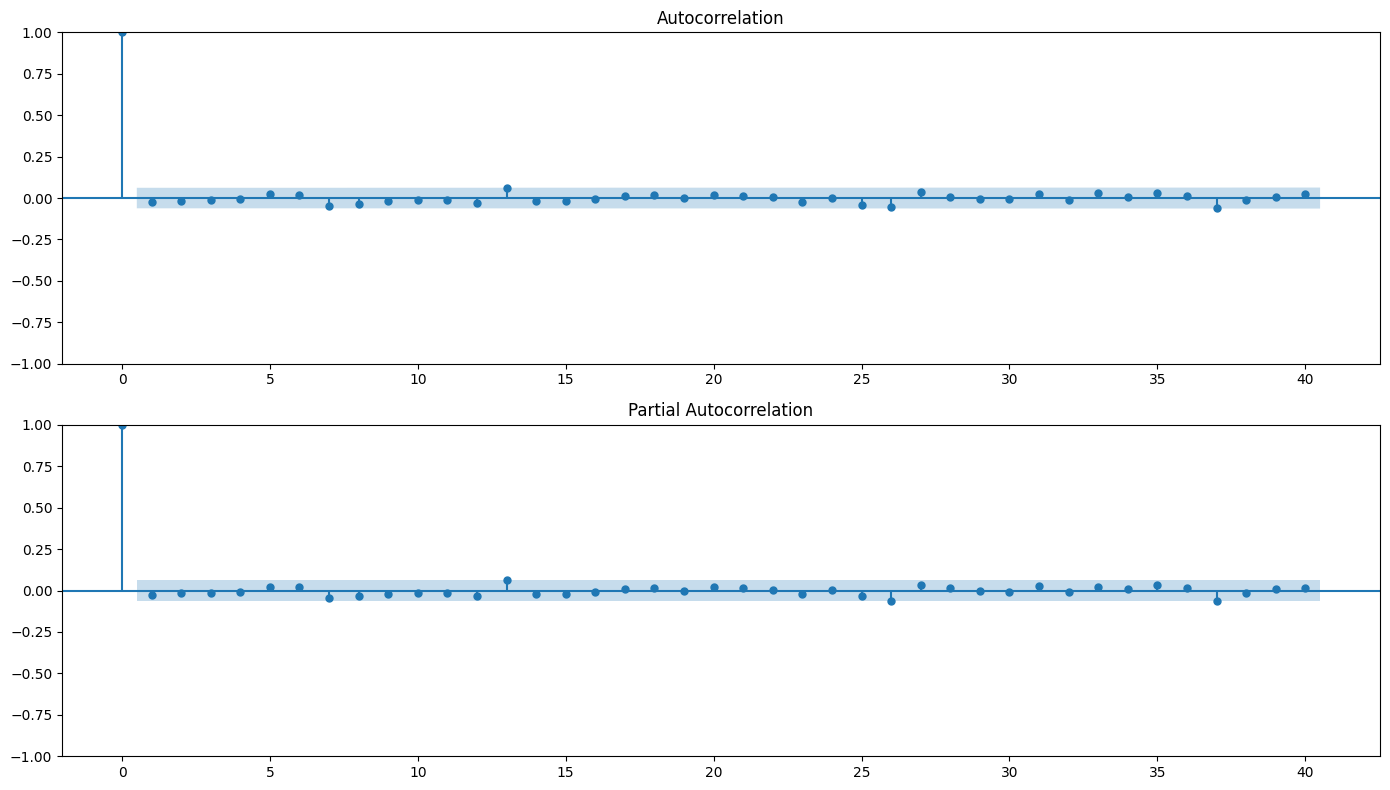

In [5]:
print("\n" + "=" * 60)
print("STEP 4: ACF & PACF ANALYSIS")
print("=" * 60)
 
stationary_series = df['Close_Diff1'].dropna()
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(stationary_series, lags=40, ax=axes[0])
plot_pacf(stationary_series, lags=40, ax=axes[1])
plt.tight_layout()
plt.show()

In [6]:
print("\n" + "=" * 60)
print("STEP 5: TESTING SEASONAL PERIODS")
print("=" * 60)

seasonal_configs = {"m=5 (Weekly)": 5, "m=21 (Monthly)": 21}
for label, m in seasonal_configs.items():
    model_test = pm.auto_arima(train_data, seasonal=True, m=m, stepwise=True, trace=False)
    print(f"Best AIC for {label}: {model_test.aic():.2f}")


STEP 5: TESTING SEASONAL PERIODS
Best AIC for m=5 (Weekly): 4202.52
Best AIC for m=21 (Monthly): 4202.52


In [7]:
print("\n" + "=" * 60)
print("STEP 6: AUTO-ARIMA - NON-SEASONAL")
print("=" * 60)
 
auto_arima_model = pm.auto_arima(train_data, seasonal=False, stepwise=True, trace=True)
best_p, best_d, best_q = auto_arima_model.order
print(f"\nSelected ARIMA order: p={best_p}, d={best_d}, q={best_q}")


STEP 6: AUTO-ARIMA - NON-SEASONAL
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=4206.042, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=4204.435, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=4206.095, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=4206.084, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4202.521, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=4208.045, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.250 seconds

Selected ARIMA order: p=0, d=1, q=0


In [8]:
print("\n" + "=" * 60)
print("STEP 7: AUTO-SARIMA - SEASONAL (m=5)")
print("=" * 60)
 
auto_sarima_model = pm.auto_arima(train_data, seasonal=True, m=5, stepwise=True, trace=True)
best_P, best_D, best_Q, best_m = auto_sarima_model.seasonal_order
print(f"\nSelected SARIMA order: ({best_p},{best_d},{best_q})({best_P},{best_D},{best_Q})[{best_m}]")


STEP 7: AUTO-SARIMA - SEASONAL (m=5)
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=4210.022, Time=0.51 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=4204.435, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=4208.013, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=4208.000, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=4202.521, Time=0.00 sec
 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=4206.374, Time=0.01 sec
 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=4206.373, Time=0.02 sec
 ARIMA(0,1,0)(1,0,1)[5] intercept   : AIC=4208.375, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[5] intercept   : AIC=4206.095, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[5] intercept   : AIC=4206.084, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[5] intercept   : AIC=4208.045, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[5]          
Total fit time: 0.756 seconds

Selected SARIMA order: (0,1,0)(0,0,0)[5]



STEP 8: ARIMA DIAGNOSTICS


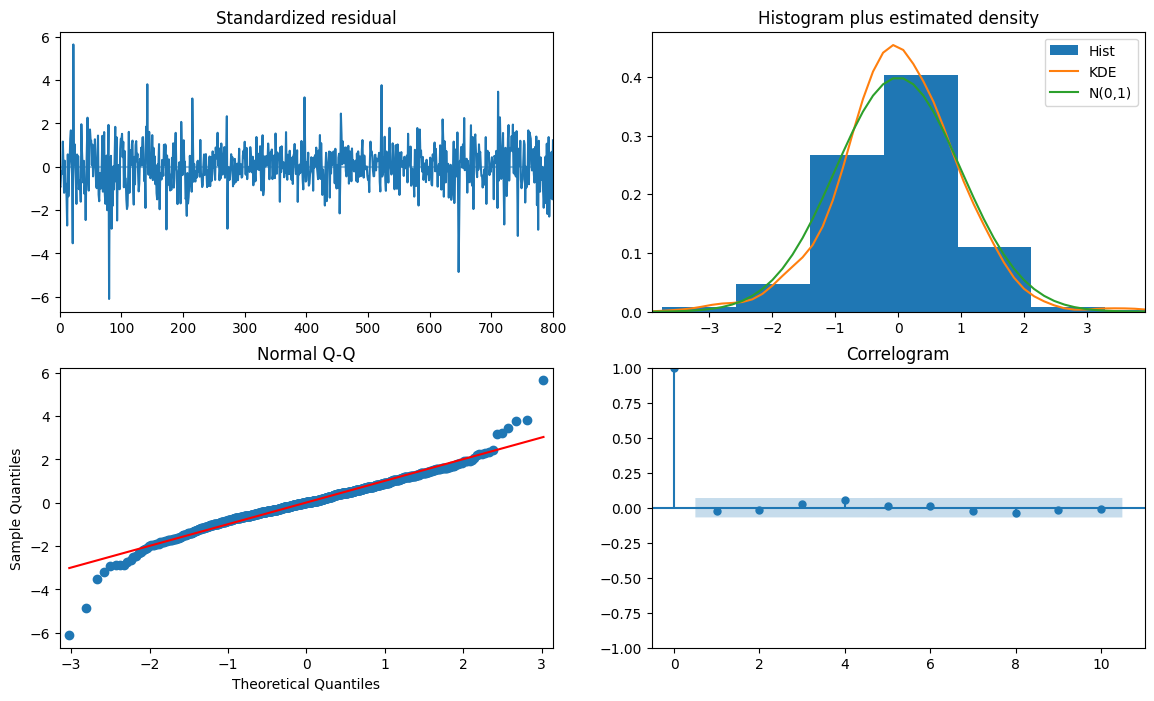

In [9]:
print("\n" + "=" * 60)
print("STEP 8: ARIMA DIAGNOSTICS")
print("=" * 60)
auto_arima_model.plot_diagnostics(figsize=(14, 8))
plt.show()


STEP 9: SARIMA DIAGNOSTICS


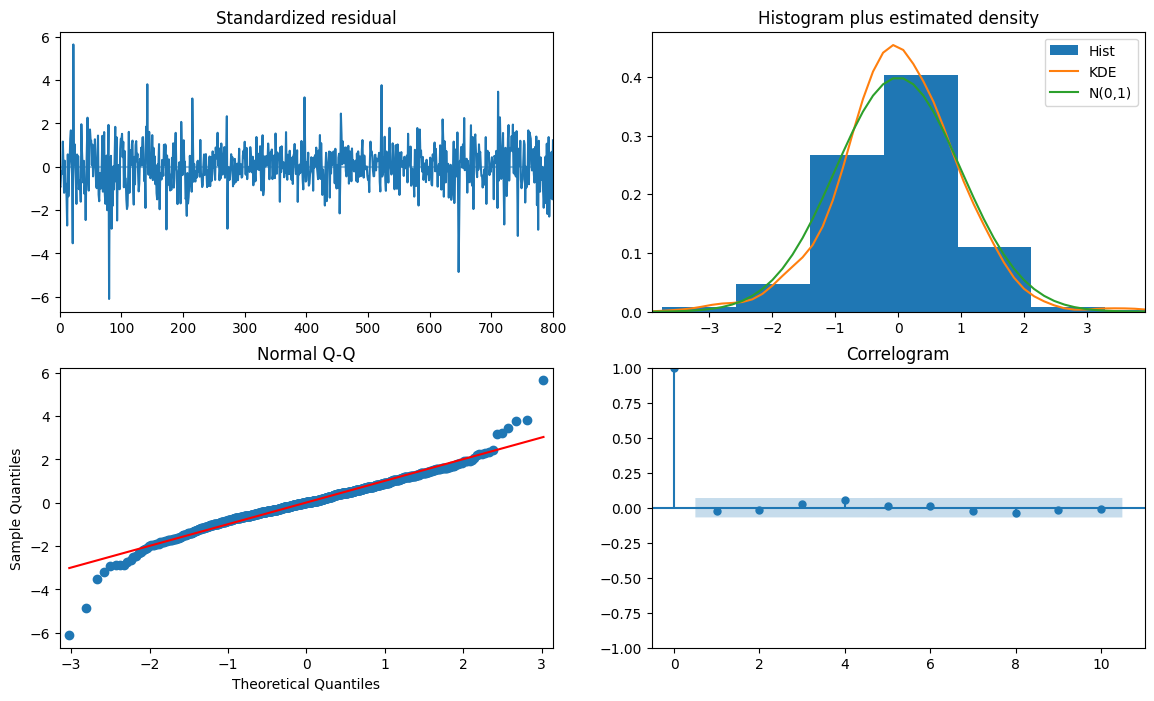

In [10]:
print("\n" + "=" * 60)
print("STEP 9: SARIMA DIAGNOSTICS")
print("=" * 60)
auto_sarima_model.plot_diagnostics(figsize=(14, 8))
plt.show()


STEP 10: ARIMA FORECASTING


/Users/williamkesuma/Desktop/William/THESIS/Thesis code/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


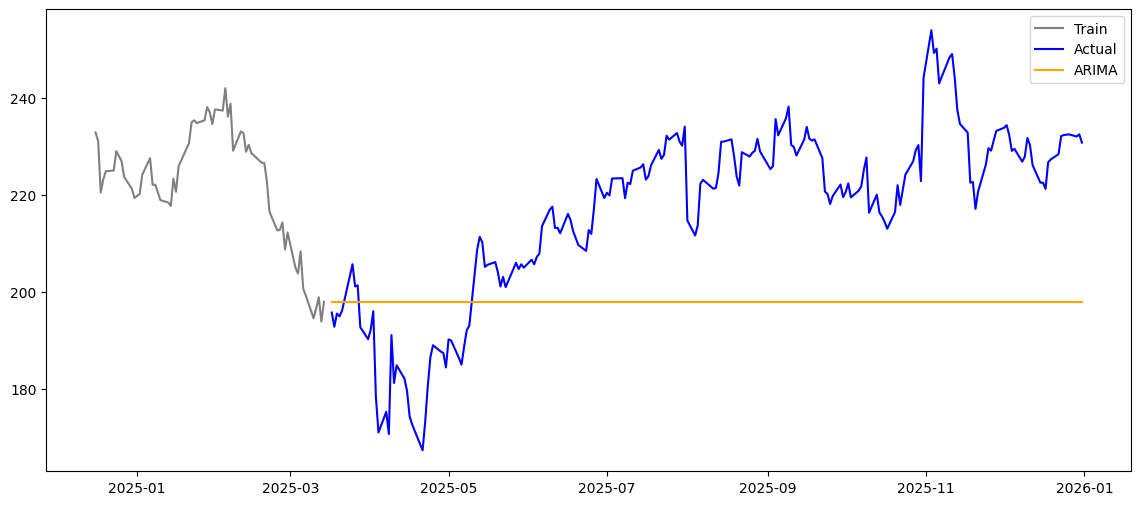

In [11]:
print("\n" + "=" * 60)
print("STEP 10: ARIMA FORECASTING")
print("=" * 60)
 
arima_forecast = auto_arima_model.predict(n_periods=len(test_data))
arima_forecast_series = pd.Series(arima_forecast.values, index=test_data.index)

plt.figure(figsize=(14, 6))
plt.plot(train_data.iloc[-60:], label='Train', color='gray')
plt.plot(test_data, label='Actual', color='blue')
plt.plot(arima_forecast_series, label='ARIMA', color='orange')
plt.legend()
plt.show()


STEP 11: SARIMA FORECASTING


/Users/williamkesuma/Desktop/William/THESIS/Thesis code/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


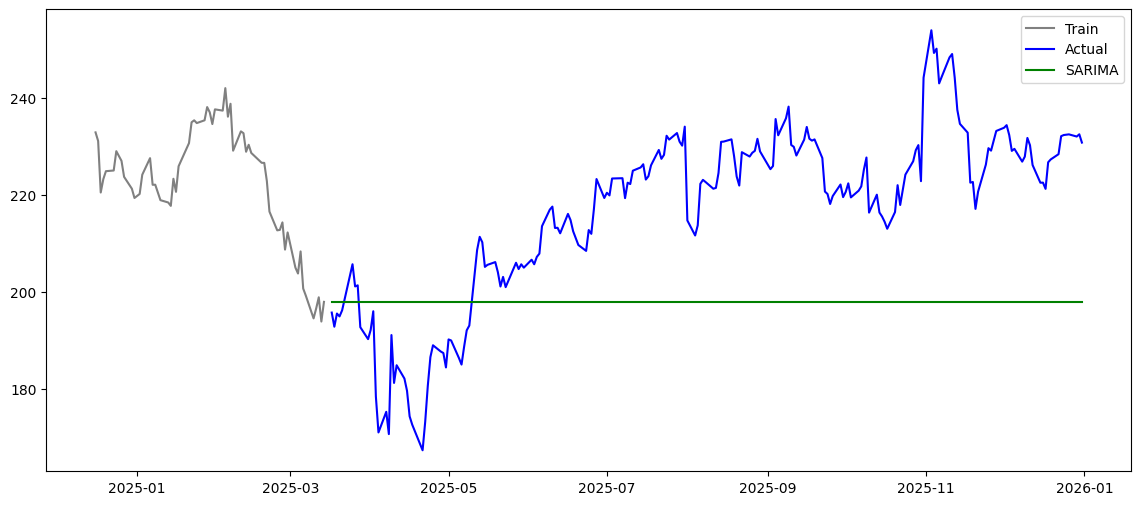

In [12]:
print("\n" + "=" * 60)
print("STEP 11: SARIMA FORECASTING")
print("=" * 60)

sarima_forecast = auto_sarima_model.predict(n_periods=len(test_data))
sarima_forecast_series = pd.Series(sarima_forecast.values, index=test_data.index)

plt.figure(figsize=(14, 6))
plt.plot(train_data.iloc[-60:], label='Train', color='gray')
plt.plot(test_data, label='Actual', color='blue')
plt.plot(sarima_forecast_series, label='SARIMA', color='green')
plt.legend()
plt.show()


STEP 12: COMBINED FORECAST COMPARISON


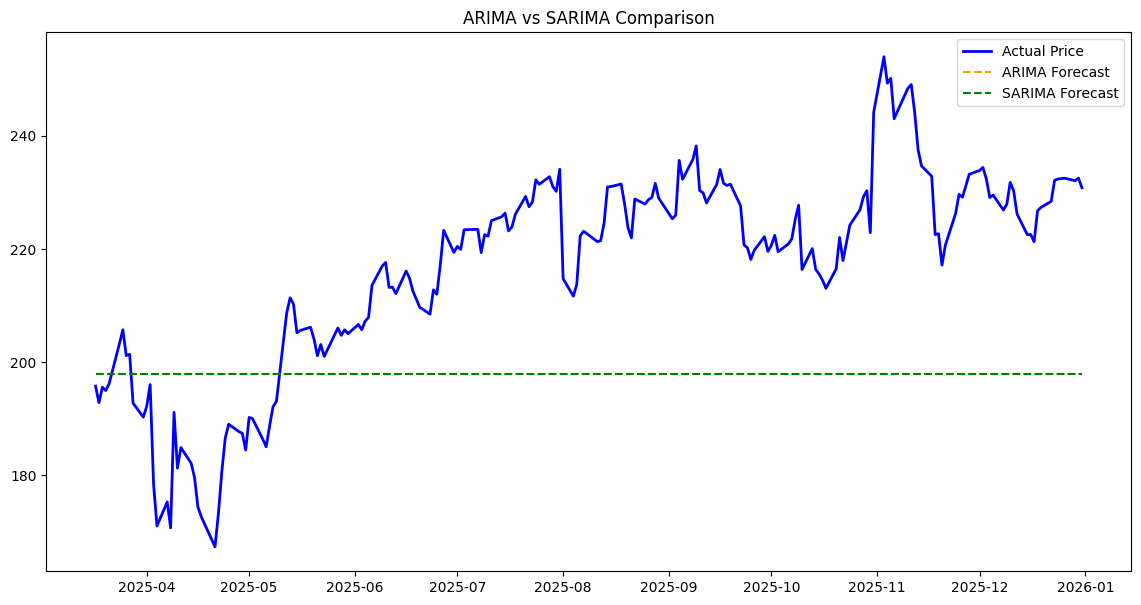

In [13]:
print("\n" + "=" * 60)
print("STEP 12: COMBINED FORECAST COMPARISON")
print("=" * 60)

plt.figure(figsize=(14, 7))
plt.plot(test_data, label='Actual Price', color='blue', linewidth=2)
plt.plot(arima_forecast_series, label='ARIMA Forecast', color='orange', linestyle='--')
plt.plot(sarima_forecast_series, label='SARIMA Forecast', color='green', linestyle='--')
plt.title("ARIMA vs SARIMA Comparison")
plt.legend()
plt.show()

In [14]:
print("\n" + "=" * 60)
print("STEP 13: PERFORMANCE METRICS")
print("=" * 60)

def evaluate(actual, predicted, name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    return {'Model': name, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'MAPE (%)': round(mape, 4)}

results = pd.DataFrame([
    evaluate(test_data, arima_forecast_series, "ARIMA"),
    evaluate(test_data, sarima_forecast_series, "SARIMA")
])

print(results.to_string(index=False))
best = results.loc[results['MAPE (%)'].idxmin(), 'Model']
print(f"\n>>> BEST MODEL: {best} <<<")


STEP 13: PERFORMANCE METRICS
 Model    RMSE     MAE  MAPE (%)
 ARIMA 25.8214 23.1745   10.4446
SARIMA 25.8214 23.1745   10.4446

>>> BEST MODEL: ARIMA <<<
